# Classical Orbits and Their Initial Conditions

### How do the initial conditions of a gravitationally bound system change the stability, path, and properties of the orbits?

##### An analysis of classical orbits by Yan Kai Chng, Ethan Hogan, Alejandro Balderas Munoz, and Owen Sliger

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd

The first objective to creating a simulation of gravitational orbits is to find what matters:

We decided that for any gravitational system, we could treat the objects as point masses, objects that have no volume or internal rotation, but contain a theoretical mass, position, and momentum. Since we want to focus on interactions within the system, we chose to exclude any external energies. Meaning that the only force in our system is the force between the objects. We also assumed that there would be no friction or drag, and that objects would not collide or merge together. We believe that these assumption would not affect the core question of initial conditions and orbital behavior.

There is another way of approaching this problem that is by using energy. The reason why we chose not to go with that route is because one the math behind using energy is more complex which can lead to more issues occuring later on. The second it would limit us to the number of mass bobies we want to use. The standard force equation allows us to expand this model further for example

For the sake of interest, we are also treating the objects as 'stars' and 'planets', i.e. our gravitational systems will have a very wide range of masses with no electromagnetic interaction; and we will continue to imagine that our simulation is modeling a celestial system in empty space. This connection will allow us to use our findings to relate the initial conditions of a simulation to real world phenomena and orbital mechanics. 

---

To simulate multi-body gravity, we are going to need a way to describe and track the information tied to our celestial bodies. 

An object in motion, under some force can be described by its:

- mass value
- position in x,y,z space
- momentum in x,y,z space
- and the force on the object in x,y,z space

To unify all of these variables under one designated object, our group decided to use numpy arrays

In [2]:
N = 3
objects = np.zeros([N,10], dtype='object')

for n in range(N):
    objects[n,0:10] = ([f'm{n}', f'x{n}', f'y{n}', f'z{n}', f'px{n}', f'py{n}', f'pz{n}', f'fx{n}', f'fy{n}', f'fz{n}'])

print(f'System 1: \n {objects} \n')

N = 5
objects = np.zeros([N,10], dtype='object')

for n in range(N):
    objects[n,0:10] = ([f'm{n}', f'x{n}', f'y{n}', f'z{n}', f'px{n}', f'py{n}', f'pz{n}', f'fx{n}', f'fy{n}', f'fz{n}'])

print(f'System 2: \n {objects} \n')

System 1: 
 [['m0' 'x0' 'y0' 'z0' 'px0' 'py0' 'pz0' 'fx0' 'fy0' 'fz0']
 ['m1' 'x1' 'y1' 'z1' 'px1' 'py1' 'pz1' 'fx1' 'fy1' 'fz1']
 ['m2' 'x2' 'y2' 'z2' 'px2' 'py2' 'pz2' 'fx2' 'fy2' 'fz2']] 

System 2: 
 [['m0' 'x0' 'y0' 'z0' 'px0' 'py0' 'pz0' 'fx0' 'fy0' 'fz0']
 ['m1' 'x1' 'y1' 'z1' 'px1' 'py1' 'pz1' 'fx1' 'fy1' 'fz1']
 ['m2' 'x2' 'y2' 'z2' 'px2' 'py2' 'pz2' 'fx2' 'fy2' 'fz2']
 ['m3' 'x3' 'y3' 'z3' 'px3' 'py3' 'pz3' 'fx3' 'fy3' 'fz3']
 ['m4' 'x4' 'y4' 'z4' 'px4' 'py4' 'pz4' 'fx4' 'fy4' 'fz4']] 



With these mock 'objects' arrays, we can see how different systems with different numbers of bodies can track all the variables we need by storing and changing the properties of each object depending on position of the variable in the numpy array. Our group used the convention:

Column 0 = mass

Column 1, 2, 3 = x-position, y-position, z-position

Column 4, 5, 6 = x-momentum, y-momentum, z-momentum

Column 7, 8, 9 = x-force, y-force, z-force

This creates segmented vectors that describe each property that we care about for each body. $\vec{r}$ represents the position vector from the origin $objects[:,1:4]$, $\vec{p}$ represents the momentum vector from the bodies position $objects[:,4:7]$, and $\vec{F}$ represents the force vector on the body $objects[:,7:10]$

---

Since the bodies are only gravitationally bound, we are going to need to derive a force equation that can be generalized for any body and its state.

We can starts with Newton's law of universal gravitation, which states that:

$$F = \frac{G m_1 m_2}{r^2},$$

where G is the graviational constant, m1 and m2 is the mass of object 1 and 2, and r is the distance between our two masses. 


However, we need to re-express this so that the force of gravity is a vector in 3D space instead of a magnitude.

To do this, we can just add a vector direction, $\hat{r}$, to the equation, giving us: $$F = \frac{G m_1 m_2}{r^2}\hat{r},$$
which isn't useful in its current state since we dont want to redine our coordinate system for every object.

Instead, we can find the positional vector $\vec{r}$ between two bodies, which would point in the exact direction that we would want the force to be in. Using the fact that $\hat{r} = \frac{\vec{r}}{r}$, where r is the distance between the bodies $|\vec{r}|$, we find that: $$F = \frac{G m_1 m_2}{r^3}\vec{r}$$

While this equation is nearly ready to be translated to code and used to find the force between our celestial bodies, there is a flaw due to our assumptions that may cause issues in extreme ellipstical orbits. Point masses do not have size, so they can get infinitely close, or r can get infinitely small, meaning we would have a force singularity. Our group decided that the best way to address this is to add a length softener, that does not effect the force at large distances, but does when r approaches 0. This length softening needs to be acted to the same degree, meaning that when we take the dot product to find the magntiude of $\vec{r}$, we need to add the length softening squared before it is square rooted to get the magnitude of distance. Finally, this gives us our force equation between two objects: $$F = \frac{G m_1 m_2 \vec{r}}{\left((\vec{r}\cdot\vec{r}) + l^2)^{3/2}\right)},$$
where $\vec{r}\cdot\vec{r} = r^2$, and $l =$ length softening.

Now we can define our main simulation function. For any Nth body in the array, we want to calculate the force between it and every other body in the array. This can be achieved with a nested for loop, with the caveat that we do not want the object to calculate the force on itself.

In [3]:
def force_calculation(objects, N, G, soft_len, dt, frame_num):
    #Sets force equal to 0
    objects[:,7:10] = 0
    
    #Records current object position and frame
    if frame_num % frame_skip == 0:
        for i in range(N):
            frames.append((objects[i,1], objects[i,2], objects[i,3], str(i), frame_num/frame_skip))
    
    #Calculating the force between every object
    for i in range(N):
        for j in range(i+1,N):
            if i != j:
                r = objects[j,1:4] - objects[i,1:4]
                r_dot = np.dot(r,r)
                
                F = -G * objects[i,0] * objects[j,0] * (r / (r_dot + soft_len**2)**1.5)
                
                objects[i,7:10] -= F
                objects[j,7:10] += F
                
    #Updating momentum
    objects[:,4:7] += objects[:,7:10] * dt
    
    #Updating Position
    for i in range(N): #Put in for loop so that mass is a scalar instead of an array of different shape from momentum. [find better solution?]
        objects[i,1:4] += (objects[i,4:7] / objects[i,0]) * dt
    
    return(frames, objects[:,4:7])

To represent the objects in 3D space, we chose to use the plotting module plotly, which has a function called scatter_3d. This function can represent points in 3D space as long as the values are given some label. That is why the numpy array is convered to a dataframe with pandas. Scatter_3d also has  abuilt in animate function, which allows us to give the function frames of animation do display with a slider or play button. This gives a very clean visual of all of the objects as they move through our simulated space. This animation is also the source of the frame skip argument in the force equation, which just tells the frame list when to save the values of position for each object, reducing resources and time of the simulation.

In [4]:
def anim_plot(df,R,title):
    fig = px.scatter_3d(
        df,
        x='x',
        y='y',
        z='z',
        color='object',
        animation_frame='frame',
        title=title,
        width=600, 
        height=600,
    )

    fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 10
    fig.layout.updatemenus[0].buttons[0].args[1]['transition']['duration'] = 1

    fig.update_layout(
        scene=dict(
            xaxis=dict(range=[-2*R, 2*R]),
            yaxis=dict(range=[-2*R, 2*R]),
            zaxis=dict(range=[-2*R, 2*R]),
            aspectmode='cube'
        )
    )
    
    return(fig)

## Difference in Two Body Elliptical Orbits

The following animations are a culmination of the simulation we have made thus far. Figure 1, 2 and 3 all have the same masses and initial positions, but slighly different intital momentums. This leads to very different orbital paths that relate velocity, radius, and mass.

As our control problem, we want a balanced, stable, and circular planetary orbit around a planet. For this to be true, we need the acceleration due to the force of gravity on the planet from the star to be equal to the centripetal acceleration of the planet due to its tangential velocity. We can balance these quantities by using the net force derived by Newton's law of universal gravitation, and by multiplying centripetal acceleration $\frac{v_{tan}^2}{r_{planet}}$ by the mass of the planet. Doing some algebra, we arrive at the equation: $$v_{tan} = \sqrt{\frac{G\left(m_{star}+m_{planet}\right)}{r}}$$

To use this, we can create a tangent vector to the approximate center of mass (0,0,0), and apply this tangential magnitude we calculated. For our planet, the orthogonal vector to the position vector is pointing in the $\hat{y}$ direction, and has a magntiude of: $$\sqrt{\frac{1\left(5000+1\right)}{100}} = 7.07177488329$$

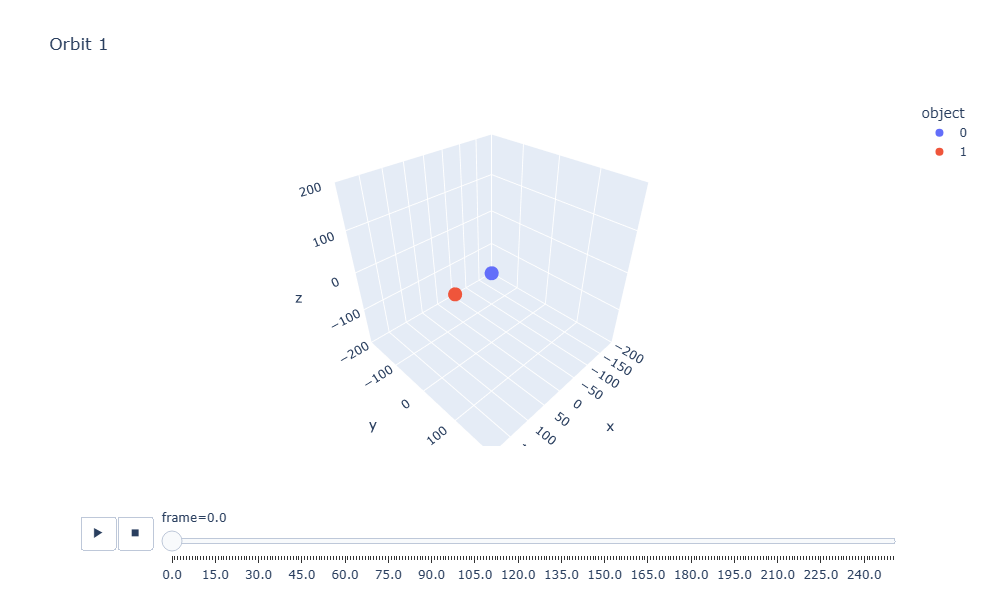

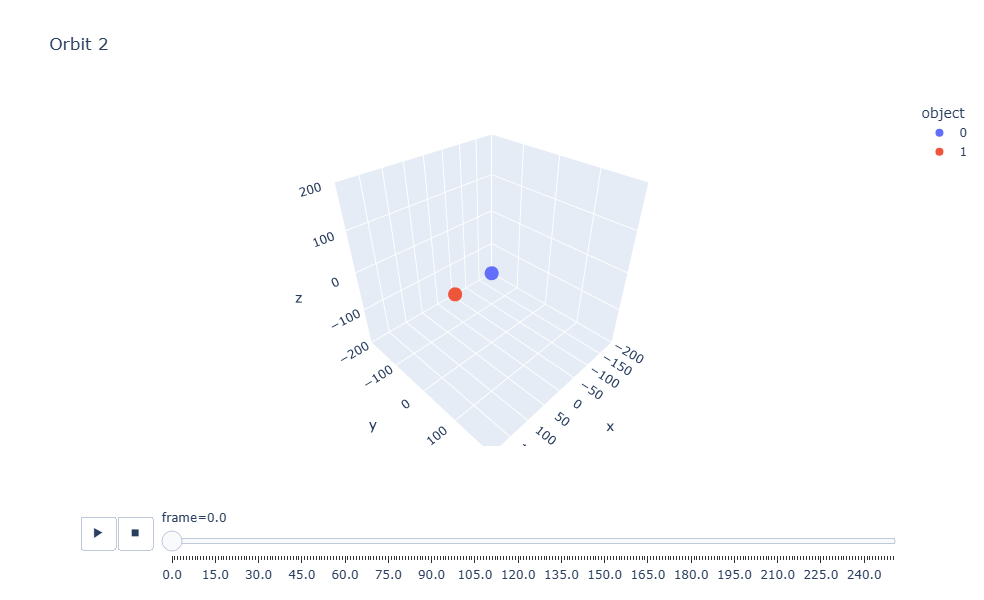

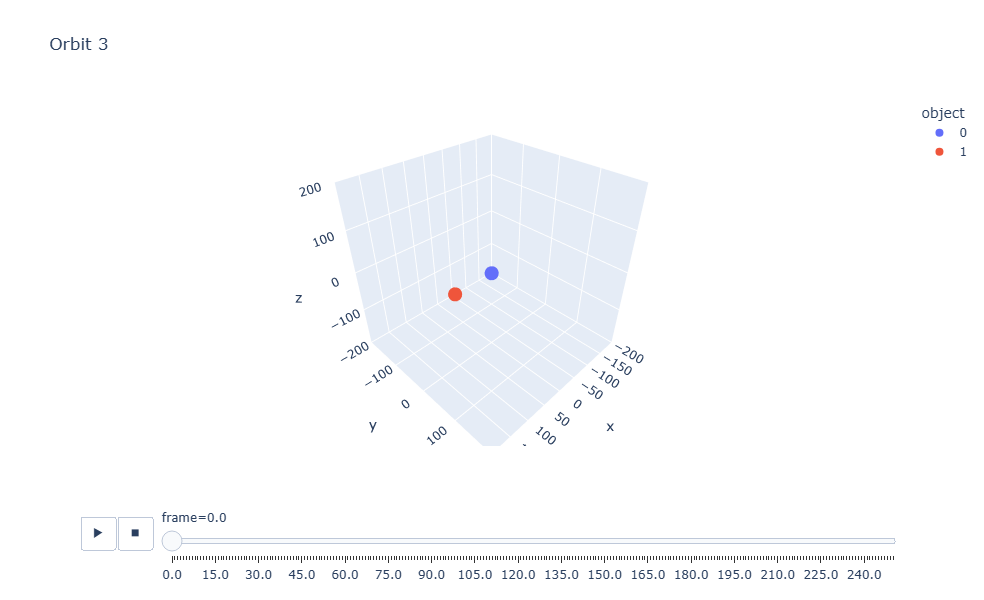

In [5]:
# Orbit 1

N = 2 # Number of objects
G = 1 # Gravitational Constant (set to 1 for simplicity, can be changed to real value if desired)

sm0 = 5000 # Mass of the star
rsx0 = 0 ; rsy0 = 0 ; rsz0 = 0 #Initial position of the star
vsx0 = 0 ; vsy0 = 0 ; vsz0 = 0 # Initial velocity of the star
m0 = 1 # Mass of the planet
rx0 = 100 ; ry0 = 0 ; rz0 = 0 #Intitial position of the planet
vx0 = 0 ; vy0 = 7.07177488329 ; vz0 = 0 #Intital velocity of the planet
R = (rx0**2 + ry0**2 + rz0**2)**(1/2) # Maximum radius for plot

dt = 0.01 # Timestep
Time = 250 # Duration of the simulation
frame_skip = 100 # Number of timesteps between frames
soft_len = 0.1 # Softening Length to prevent singularities in force calculations when objects get very close to each other

frames = [] # Setting the empty frame list
frame_num = 0 # Intializing frame number
t = 0 # Intializing time

objects0 = np.zeros([N,10])

objects0[0,0] = sm0
objects0[0,1:4] = np.array((rsx0, rsy0, rsz0))
objects0[0,4:7] = sm0 * np.array((vsx0, vsy0, vsz0))

objects0[1,0] = m0
objects0[1,1:4] = np.array((rx0, ry0, rz0))
objects0[1,4:7] = m0 * np.array((vx0, vy0, vz0))

vel0 = np.zeros(int(Time/dt))

while t<Time:
    frames, objects0[:,4:7] = force_calculation(objects0, N, G, soft_len, dt, frame_num)

    if frame_num < Time/dt:
        
        vel0[int(frame_num)] = (
            (objects0[1,4]/objects0[1,0])**2 + (objects0[1,5]/objects0[1,0])**2 + (objects0[1,6]/objects0[1,0])**2
        )**(1/2)
        
    t += dt
    frame_num += 1

# Converting saved position data into a format that px.scatter_3d can use
df = pd.DataFrame(frames, columns=['x','y','z','object','frame'])

fig = anim_plot(df, R, 'Orbit 1')
fig.show()



#Orbit 2

sm0 = 5000 # Mass of the star
rsx0 = 0 ; rsy0 = 0 ; rsz0 = 0 #Initial position of the star
vsx0 = 0 ; vsy0 = 0 ; vsz0 = 0 # Initial velocity of the star
m0 = 1 # Mass of the planet
rx0 = 100 ; ry0 = 0 ; rz0 = 0 #Intitial position of the planet
vx0 = 0 ; vy0 = 5 ; vz0 = 0 #Intital velocity of the planet
R = (rx0**2 + ry0**2 + rz0**2)**(1/2) # Maximum radius for plot

frames = [] # Setting the empty frame list
frame_num = 0 # Intializing frame number
t = 0 # Intializing time

objects1 = np.zeros([N,10])

objects1[0,0] = sm0
objects1[0,1:4] = np.array((rsx0, rsy0, rsz0))
objects1[0,4:7] = sm0 * np.array((vsx0, vsy0, vsz0))

objects1[1,0] = m0
objects1[1,1:4] = np.array((rx0, ry0, rz0))
objects1[1,4:7] = m0 * np.array((vx0, vy0, vz0))

vel1 = np.zeros(int(Time/dt))

while t<Time:
    force_calculation(objects1, N, G, soft_len, dt, frame_num)
    
    if frame_num < Time/dt:

        vel1[int(frame_num)] = (
            (objects1[1,4]/objects1[1,0])**2 + (objects1[1,5]/objects1[1,0])**2 + (objects1[1,6]/objects1[1,0])**2
        )**(1/2)
        
    t += dt
    frame_num += 1
    
# Converting saved position data into a format that px.scatter_3d can use
df1 = pd.DataFrame(frames, columns=['x','y','z','object','frame'])

fig1 = anim_plot(df1, R, 'Orbit 2')
fig1.show()



#Orbit 3

sm0 = 5000 # Mass of the star
rsx0 = 0 ; rsy0 = 0 ; rsz0 = 0 #Initial position of the star
vsx0 = 0 ; vsy0 = 0 ; vsz0 = 0 # Initial velocity of the star
m0 = 1 # Mass of the planet
rx0 = 100 ; ry0 = 0 ; rz0 = 0 #Intitial position of the planet
vx0 = 1 ; vy0 = 1 ; vz0 = 1 #Intital velocity of the planet
R = (rx0**2 + ry0**2 + rz0**2)**(1/2) # Maximum radius for plot

frames = [] # Setting the empty frame list
frame_num = 0 # Intializing frame number
t = 0 # Intializing time

objects2 = np.zeros([N,10])

objects2[0,0] = sm0
objects2[0,1:4] = np.array((rsx0, rsy0, rsz0))
objects2[0,4:7] = sm0 * np.array((vsx0, vsy0, vsz0))

objects2[1,0] = m0
objects2[1,1:4] = np.array((rx0, ry0, rz0))
objects2[1,4:7] = m0 * np.array((vx0, vy0, vz0))

vel2 = np.zeros(int(Time/dt))

while t<Time:
    force_calculation(objects2, N, G, soft_len, dt, frame_num)
    
    if frame_num < Time/dt:
        
        vel2[int(frame_num)] = (
            (objects2[1,4]/objects2[1,0])**2 + (objects2[1,5]/objects2[1,0])**2 + (objects2[1,6]/objects2[1,0])**2
        )**(1/2)
    
    t += dt
    frame_num += 1
    
# Converting saved position data into a format that px.scatter_3d can use
df2 = pd.DataFrame(frames, columns=['x','y','z','object','frame'])

fig2 = anim_plot(df2, R, 'Orbit 3')
fig2.show()

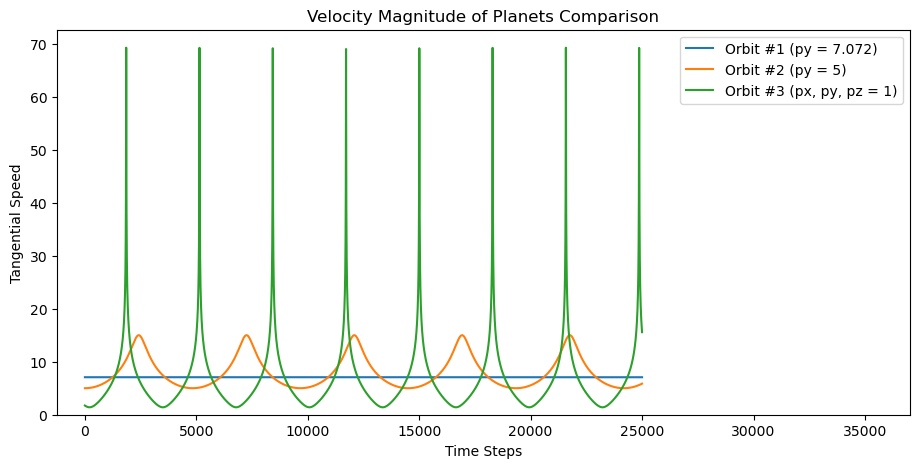

In [6]:
time = np.arange(0,int(Time/dt),1)

plt.figure(figsize=(11, 5))
plt.plot(time, vel0, label='Orbit #1 (py = 7.072)')
plt.plot(time, vel1, label='Orbit #2 (py = 5)')
plt.plot(time, vel2, label='Orbit #3 (px, py, pz = 1)')
plt.axis(ymin=0, xmax=37000)
plt.title('Velocity Magnitude of Planets Comparison')
plt.xlabel('Time Steps')
plt.ylabel('Tangential Speed')
plt.legend();

## Stable Binary Star System

A very intersting way to see the delicate nature of multi-body gravitational systems is to simulate a binary system with many planets orbiting it. In the first cell, we use similar force balancing to the previous model to create circular orbits of the planets around the center of mass. Using a sligthly different equation that uses the center of mass between two large objects, and creates a stable orbit between the two.

First we need a standardized equation to find the orthogonal momentum vector from the center of mass to the planetary object, in the positive theta direction relative to an orbital plane.

To do this, we find $r_{cm}$ using: $$\sum_{n=0}^{N} \frac{m_n \vec{r}_n}{M},$$
where M is the sum of all masses. With $r_{cm}$, we can find the relative $\vec{r}$ by subtracting $r_{cm}$ by the position vector. This allows us to find $\hat{r}$, which can find the orthogonal vector by taking the cross product. Then we can multiply the normalized cross product by the magntide of velocity and the mass of the planet as used in the previous simulation to find the stable momentum vector for any planet in any position.

In [7]:
def initial_planet_p(objects, N, r_cm, orbital_plane):
    for n in range(2,N):
        r = r_cm - np.array([objects[n,1], objects[n,2], objects[n,3]])
        r_mag = np.linalg.norm(r)
        r_hat  = r/r_mag

        theta_hat = np.cross(orbital_plane, r_hat)
        theta_hat /= np.linalg.norm(theta_hat)

        s = (G * ((sm0 + sm1) + objects[n,0]) / r_mag)**(1/2)
        objects[n,4:7] = objects[n,0] * s * theta_hat
        
    return(objects[2:N,4:7])

Similarly, we can calculate the intital stable momentum of the stars by using the same equation as before, but with the center of mass between the two stars. This equation has a factor of $r^3$ as the distances in the angular acceleration doesnt cancel out with the force. We also account for the conservation of angular momentum due to no external force by setting the two momentum sum to 0.

In [8]:
def intital_star_p(objects, sm0, sm1, orbital_plane):

    r_star = objects[1,1:4] - objects[0,1:4]
    r_star_mag = np.linalg.norm(r_star)
    r_star_hat = r_star / r_star_mag

    theta_star_hat = np.cross(orbital_plane, r_star_hat)
    theta_star_hat /= np.linalg.norm(theta_star_hat)

    s_star = (G * (sm0 + sm1) / r_star_mag**3)**(1/2)

    R0 = sm1 * r_star_mag / (sm0 + sm1)
    R1 = sm0 * r_star_mag / (sm0 + sm1)

    s0 = s_star * R0
    s1 = s_star * R1

    objects[0,4:7] = sm0 * s0 * theta_star_hat
    objects[1,4:7] = -sm1 * s1 * theta_star_hat
    
    return(objects[0:2,4:7])

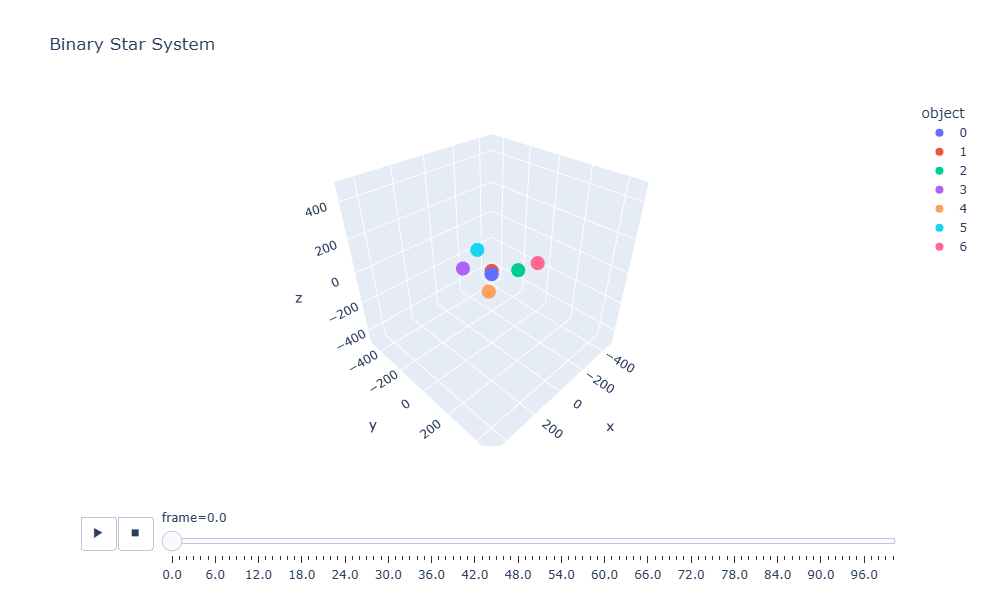

In [9]:
N = 7 # Number of objects
G = 1 # Gravitational Constant (set to 1 for simplicity, can be changed to real value if desired)

orbital_plane = np.array([0,0,1])

sm0 = 2500 # Mass of star 1
rsx0 = 25 ; rsy0 = 25 ; rsz0 = 20 #Initial position of star 1
sm1 = 2500 # Mass of star 2
rsx1 = -25 ; rsy1 = -25 ; rsz1 = -10 #Initial position of star 2

m0 = 1 # Mass of planet 1
rx0 = -150 ; ry0 = 50 ; rz0 = -30 #Intitial position of planet 1
m1 = 1 # Mass of planet 2
rx1 = 90 ; ry1 = -120 ; rz1 = 15 #Intitial position of planet 2
m2 = 1 # Mass of planet 3
rx2 = 110 ; ry2 = 90 ; rz2 = -10 #Intitial position of planet 3
m3 = 1 # Mass of planet 4
rx3 = -60 ; ry3 = -170 ; rz3 = 40 #Intitial position of planet 4
m4 = 1 # Mass of planet 5
rx4 = -210 ; ry4 = 130 ; rz4 = 25 #Intitial position of planet 5

R = (rx4**2 + ry4**2 + rz4**2)**(1/2) # Maximum radius for plot

dt = 0.01 # Timestep
Time = 250 # Duration of the simulation
frame_skip = 250 # Number of timesteps between frames
soft_len = 0.1 # Softening Length to prevent singularities in force calculations when objects get very close to each other

frames = [] # Setting the empty frame list
frame_num = 0 # Intializing frame number
t = 0 # Intializing time

# Initializing array with initial conditions
objects = np.zeros([N,10])

objects[0,0] = sm0
objects[0,1:4] = np.array((rsx0, rsy0, rsz0))

objects[1,0] = sm1
objects[1,1:4] = np.array((rsx1, rsy1, rsz1))

objects[2,0] = m0
objects[2,1:4] = np.array((rx0, ry0, rz0))

objects[3,0] = m1
objects[3,1:4] = np.array((rx1, ry1, rz1))

objects[4,0] = m2
objects[4,1:4] = np.array((rx2, ry2, rz2))

objects[5,0] = m3
objects[5,1:4] = np.array((rx3, ry3, rz3))

objects[6,0] = m4
objects[6,1:4] = np.array((rx4, ry4, rz4))

# Finding the center of mass
for n in range(N):
    r_cm = np.array([np.sum(objects[n,1])*objects[n,0], np.sum(objects[n,2])*objects[n,0], np.sum(objects[n,3])*objects[n,0]])/(np.sum(objects[:,0]))

# Calculating the initial momenta according to the equations derived
objects[2:N,4:7] = initial_planet_p(objects, N, r_cm, orbital_plane)

objects[0:2,4:7] = intital_star_p(objects, sm0, sm1, orbital_plane)

vel = np.zeros([N,int(Time/dt)])

while t<Time:
    
    frames, objects[:,4:7] = force_calculation(objects, N, G, soft_len, dt, frame_num)
    
    if frame_num < Time/dt:
        for i in range(N):
            vel[i,int(frame_num)] = (
            (objects[i,4]/objects[i,0])**2 + (objects[i,5]/objects[i,0])**2 + (objects[i,6]/objects[i,0])**2
            )**(1/2)
    
    t += dt
    frame_num += 1

# Converting saved position data into a format that px.scatter_3d can use
df = pd.DataFrame(frames, columns=['x','y','z','object','frame'])

fig = anim_plot(df, R,'Binary Star System')
fig.show()

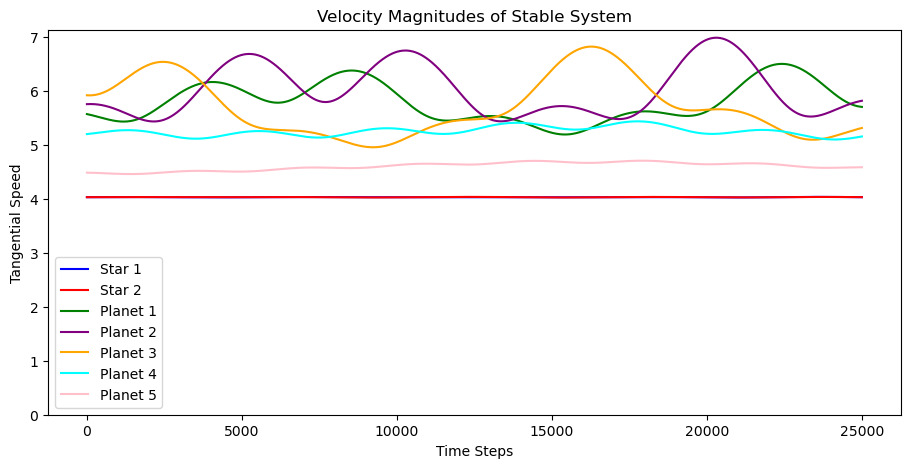

In [10]:
time = np.arange(0,int(Time/dt),1)

plt.figure(figsize=(11, 5))
plt.plot(time, vel[0,:], label='Star 1', color='blue')
plt.plot(time, vel[1,:], label='Star 2', color='red')
plt.plot(time, vel[2,:], label='Planet 1', color='green')
plt.plot(time, vel[3,:], label='Planet 2', color='purple')
plt.plot(time, vel[4,:], label='Planet 3', color='orange')
plt.plot(time, vel[5,:], label='Planet 4', color='cyan')
plt.plot(time, vel[6,:], label='Planet 5', color='pink')
plt.axis(ymin=0)
plt.title('Velocity Magnitudes of Stable System')
plt.xlabel('Time Steps')
plt.ylabel('Tangential Speed')
plt.legend();

## Slightly Unbalanced Binary Star System

To compare the stability, we can have some fun and apply a random change that can effect any quantity after stabalization. The randomization adds a random multiplier to the initital quantity between the range of -0.5 to 0.5.

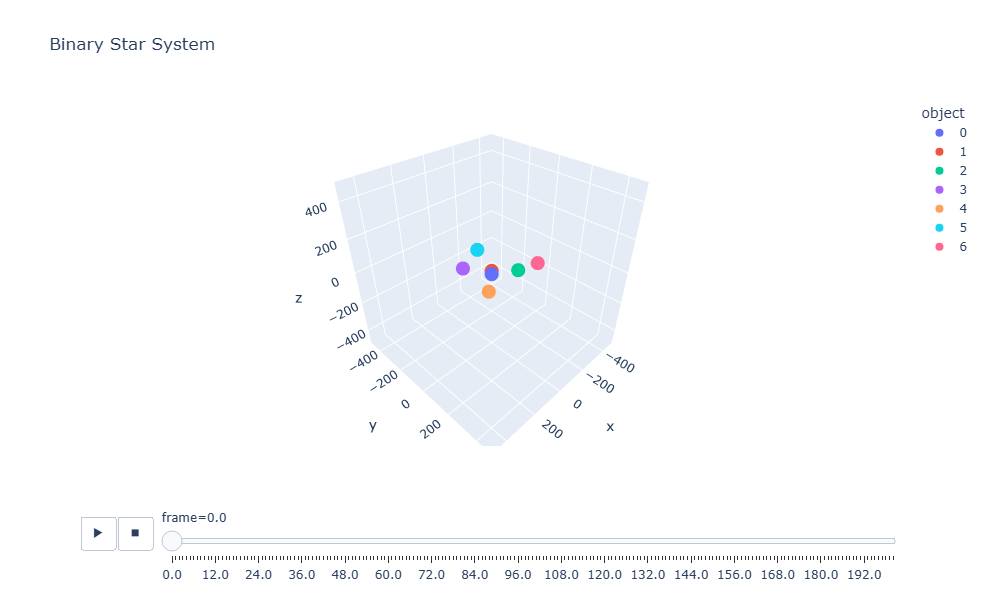

In [11]:
Time = 500 # Duration of the simulation
frame_skip = 250 # Number of timesteps between frames
soft_len = 0.1 # Softening Length to prevent singularities in force calculations when objects get very close to each other

frames = [] # Setting the empty frame list
frame_num = 0 # Intializing frame number
t = 0 # Intializing time

# Initializing array with initial conditions
objects = np.zeros([N,10])

objects[0,0] = sm0
objects[0,1:4] = np.array((rsx0, rsy0, rsz0))

objects[1,0] = sm1
objects[1,1:4] = np.array((rsx1, rsy1, rsz1))

objects[2,0] = m0
objects[2,1:4] = np.array((rx0, ry0, rz0))

objects[3,0] = m1
objects[3,1:4] = np.array((rx1, ry1, rz1))

objects[4,0] = m2
objects[4,1:4] = np.array((rx2, ry2, rz2))

objects[5,0] = m3
objects[5,1:4] = np.array((rx3, ry3, rz3))

objects[6,0] = m4
objects[6,1:4] = np.array((rx4, ry4, rz4))

# Finding the center of mass
for n in range(N):
    r_cm = np.array([np.sum(objects[n,1])*objects[n,0], np.sum(objects[n,2])*objects[n,0], np.sum(objects[n,3])*objects[n,0]])/(np.sum(objects[:,0]))

# Calculating the initial momenta according to the equations derived
objects[2:N,4:7] = initial_planet_p(objects, N, r_cm, orbital_plane)

objects[0:2,4:7] = intital_star_p(objects, sm0, sm1, orbital_plane)

for i in range(N):
    for j in range(objects[0,:].size):
        if i != j:
            objects[i,j] = objects[i,j] + (0.1 * (np.random.random()*2 - 1))

vel = np.zeros([N,int(Time/dt)])            

while t<Time:
    
    frames, objects[:,4:7] = force_calculation(objects, N, G, soft_len, dt, frame_num)
    
    if frame_num < Time/dt:
        for i in range(N):
            vel[i,int(frame_num)] = (
            (objects[i,4]/objects[i,0])**2 + (objects[i,5]/objects[i,0])**2 + (objects[i,6]/objects[i,0])**2
            )**(1/2)
    
    t += dt
    frame_num += 1

# Converting saved position data into a format that px.scatter_3d can use
df = pd.DataFrame(frames, columns=['x','y','z','object','frame'])

fig = anim_plot(df, R,'Binary Star System')
fig.show()

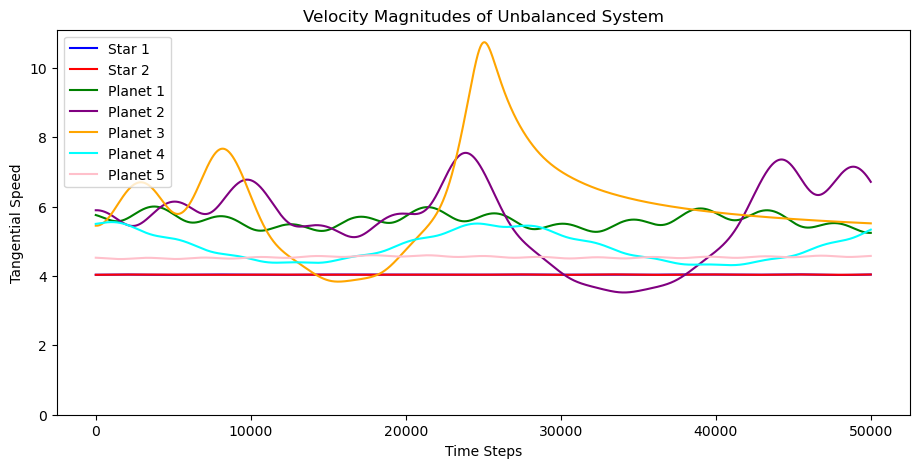

In [12]:
time = np.arange(0,int(Time/dt),1)

plt.figure(figsize=(11, 5))
plt.plot(time, vel[0,:], label='Star 1', color='blue')
plt.plot(time, vel[1,:], label='Star 2', color='red')
plt.plot(time, vel[2,:], label='Planet 1', color='green')
plt.plot(time, vel[3,:], label='Planet 2', color='purple')
plt.plot(time, vel[4,:], label='Planet 3', color='orange')
plt.plot(time, vel[5,:], label='Planet 4', color='cyan')
plt.plot(time, vel[6,:], label='Planet 5', color='pink')
plt.axis(ymin=0)
plt.title('Velocity Magnitudes of Unbalanced System')
plt.xlabel('Time Steps')
plt.ylabel('Tangential Speed')
plt.legend();

## Conclusion

Clearly, the stability of these gravitational systems are heavily influenced by the initial conditions of the system. When the initial momentum is close to a certain value there are predictable orbital patterns taken. First, there is a stable circular or slightly elliptical orbit, where the planet follows a smooth repeated oscillation around the star. However, when the initial momentum is smaller or close to parallel to the radial motion, it causes the planet to orbit close to the star and increases the speed . This can be shown in the velocity magnitude plot where there are sharper peaks corresponding to closer distance and stronger gravitational acceleration. We can conclude that the stability and shape of gravitational orbit is heavily dependent on initial momentum and direction other than initial position. If the velocity of a planet is low compared it its distance and mass, it will enter an eccentric orbit around the star, or even fall within its envelope. if the velocity is too large, it will simply exit the gravitational influence of the star it is near. 

In a many-bodied system, the initial conditions of the system almost make it seem chaotic. One small change, and the orbital paths of every object will change wildly. The slight random change highlights how the bodies are coupled, and will completely change the course of the system. We can extrapolate that stable systems in the universe most likely arrise from the coincidentally stable particles surviving, while the unstable particles either eventually fall into another object or get ejected.

While this simplified model is very interesting, the concept could be taken further by adding collisions. We could also model more unique situations to hone in the relations seen between mass, distance, and momentum. Another path could be to simulate large dust clouds and the formation of galaxies to see how these gravitational system display large, unforseen properties in very large or complex systems.

We could have also modeled the solar system with our current set up since we can calculate the force that each mass is experincing. With more time, this would have been a very interesting 'stress test' on our model. It might highlight certain energy injections or losses due to the mathematical assumptions made previously, allowing us to interate and improve the accuracy of our gravitational simulation. This avenue of simulations is vast, and many different answers could be explored with the surface level model made for this project.